In [19]:
import numpy as np
import matplotlib.pyplot as plt

def triangle(x, a, b, c, d, e):
    """
    Calculates the membership value for a triangular fuzzy function using if/elif/else.

    Parameters:
    x (float or np.array): The input value(s).
    a (float): The left-most X point, paired with y value d.
    b (float): The middle X point, paired with Y value of 1.
    c (float): The right-most X point, paired with Y value e.
    d (float): The y-value at point a.
    e (float): The y-value at point c.

    Returns:
    float or np.array: The membership value(s).
    """

    if x < a:
        return d
    elif a <= x <= b:
        if b == a:
            return 1   # shoulder kiri
        return (x - a) / (b - a)
    elif b < x <= c:
        if c == b:
            return 1   # shoulder kanan
        return (c - x) / (c - b)
    elif x > c:
        return e
    else:
        return 0

print("Running Selesai")

Running Selesai


In [20]:
def fuzzifikasi_area(x):
    sedikit = triangle(x, 0, 0, 50, 1, 0)
    sedang  = triangle(x, 25, 50, 75, 0, 0)
    banyak  = triangle(x, 50, 100, 100, 0, 1)
    return np.array([sedikit, sedang, banyak])

def fuzzifikasi_daya(x):
    kecil    = triangle(x, 0, 0, 50, 1, 0)
    menengah = triangle(x, 25, 50, 75, 0, 0)
    besar    = triangle(x, 50, 100, 100, 0, 1)
    return np.array([kecil, menengah, besar])

In [21]:
in_area = 40
in_daya = 70

fuzzy_area = fuzzifikasi_area(in_area)
fuzzy_daya = fuzzifikasi_daya(in_daya)

In [22]:
rule_output = np.array([
    [1000, 3000, 5000],    # sedikit area
    [3000, 5000, 8000],    # sedang
    [5000, 8000, 10000]    # banyak
])

In [23]:
num = 0
den = 0

for i, val_area in enumerate(fuzzy_area):
    for j, val_daya in enumerate(fuzzy_daya):
        alpha = min(val_area, val_daya)   # AND
        num += alpha * rule_output[i][j]
        den += alpha

crisp_output = num / den

In [24]:
print("Fuzzy Area:", fuzzy_area)
print("Fuzzy Daya:", fuzzy_daya)
print("Harga Paket (Crisp):", crisp_output)

Fuzzy Area: [0.2 0.6 0. ]
Fuzzy Daya: [0.  0.2 0.4]
Harga Paket (Crisp): 5800.0


In [25]:
if crisp_output < 3000:
    kategori = "Basic"
elif crisp_output < 7000:
    kategori = "Premium"
else:
    kategori = "Platinum"

print("Kategori Paket:", kategori)

Kategori Paket: Premium


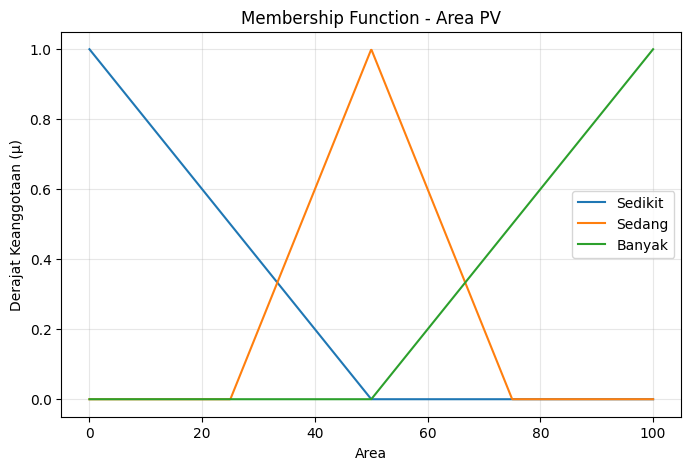

In [26]:
area_range = np.linspace(0, 100, 1000)

area_sedikit = [triangle(x, 0, 0, 50, 1, 0) for x in area_range]
area_sedang  = [triangle(x, 25, 50, 75, 0, 0) for x in area_range]
area_banyak  = [triangle(x, 50, 100, 100, 0, 1) for x in area_range]

plt.figure(figsize=(8,5))
plt.plot(area_range, area_sedikit, label='Sedikit')
plt.plot(area_range, area_sedang, label='Sedang')
plt.plot(area_range, area_banyak, label='Banyak')

plt.title("Membership Function - Area PV")
plt.xlabel("Area")
plt.ylabel("Derajat Keanggotaan (μ)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

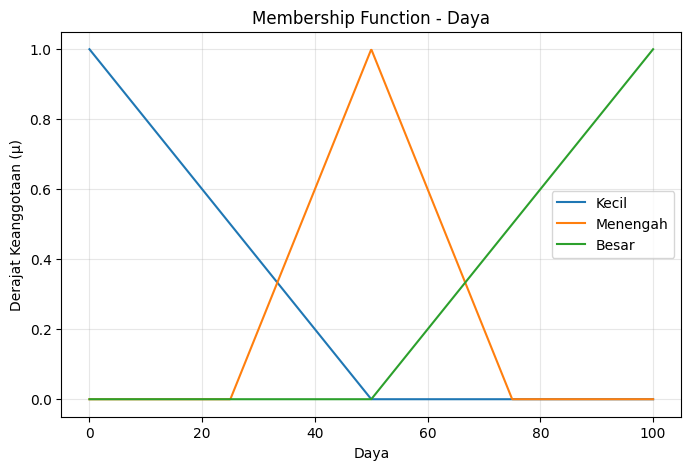

In [27]:
daya_range = np.linspace(0, 100, 1000)

daya_kecil    = [triangle(x, 0, 0, 50, 1, 0) for x in daya_range]
daya_menengah = [triangle(x, 25, 50, 75, 0, 0) for x in daya_range]
daya_besar    = [triangle(x, 50, 100, 100, 0, 1) for x in daya_range]

plt.figure(figsize=(8,5))
plt.plot(daya_range, daya_kecil, label='Kecil')
plt.plot(daya_range, daya_menengah, label='Menengah')
plt.plot(daya_range, daya_besar, label='Besar')

plt.title("Membership Function - Daya")
plt.xlabel("Daya")
plt.ylabel("Derajat Keanggotaan (μ)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

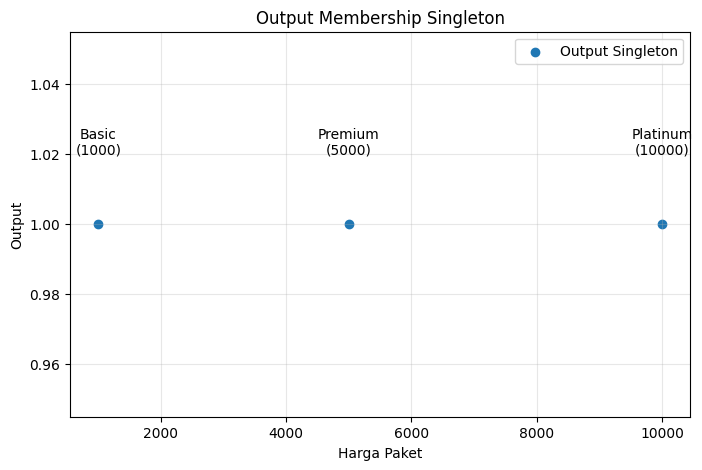

In [30]:
output_labels = ['Basic', 'Premium', 'Platinum']
output_values = [1000, 5000, 10000]

plt.figure(figsize=(8,5))
plt.scatter(output_values, [1,1,1], label='Output Singleton')

for i, label in enumerate(output_labels):
    plt.text(output_values[i], 1.02, f"{label}\n({output_values[i]})", ha='center')

plt.title("Output Membership Singleton")
plt.ylabel("Output")
plt.xlabel("Harga Paket")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()